# Workflow

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict
from IPython.display import display, Image

class AgentState(TypedDict, total=False):
    data_path: str
    metadata: dict
    validation_report: dict
    cleaning_required: bool
    cleaned_data_path: str
    analysis_report: str


def data_ingestion( ):
    """
    Reads dataset from CSV file
    Generates basic metadata about dataset
    Stores dataset file path

    Output:
        data_path
        metadata
    """
    pass


def data_validation( ):
    """
    Analyzes dataset using pandas
    Identifies missing values and duplicates
    Detects incorrect data types
    Generats validation statistics
    Output:
        validation_report
    """
    pass


def decision_router( ):
    """
    Reads validation report
    Determines if cleaning is required
    Decision based on missing values or duplicates

    Output:
        cleaning_required (True  | False )flag
    """
    pass


def data_processing( ):
    """
    Cleans dataset when issues are detected
    Handles missing values and duplicates

    Saves cleaned dataset to folder

    Output:
        Generates Code for Data preprocessing 
    """
    pass
def code_runner():
    """
    runs the Code Generated by Data_preprocesing node
    
    input : 
        data_preprocessing code
    output:
        short report
        data_preprocessing_code_output
    """
def code_fixer():
    """
    runs only if return value  is  1  in code_runner
    input : 
        ouput of Code
    output:
        fixed Code
    """

def report_generator( ):
    """
    Generates full text report from analysis results

    Output:
        final_text_report
    """
    pass


def visualization_generator( ):
    """
    Generates charts and graphs from dataset

    Output:
        visualization_paths
    """
    pass


def merge_results( ):
    """
    Combines text report and visualizations

    Output:
        final_analysis_package
    """
    pass

def univariate_analysis( ):
    """
    Performs single-variable analysis
    Example: distribution, histograms, summary stats
    """
    return {"univariate_report": "done"}


def bivariate_analysis( ):
    """
    Performs two-variable analysis
    Example: correlation, scatterplots
    """
    return {"bivariate_report": "done"}


def multivariate_analysis( ):
    """
    Performs multi-variable analysis
    Example: pairplots, feature interactions
    """
    return {"multivariate_report": "done"}
def analysis_router( ):
    """
    Entry node for analysis stage.
    Starts parallel analysis tasks.
    """
    return {}

def final_report():
    """ combines the report and visualization"""
    pass

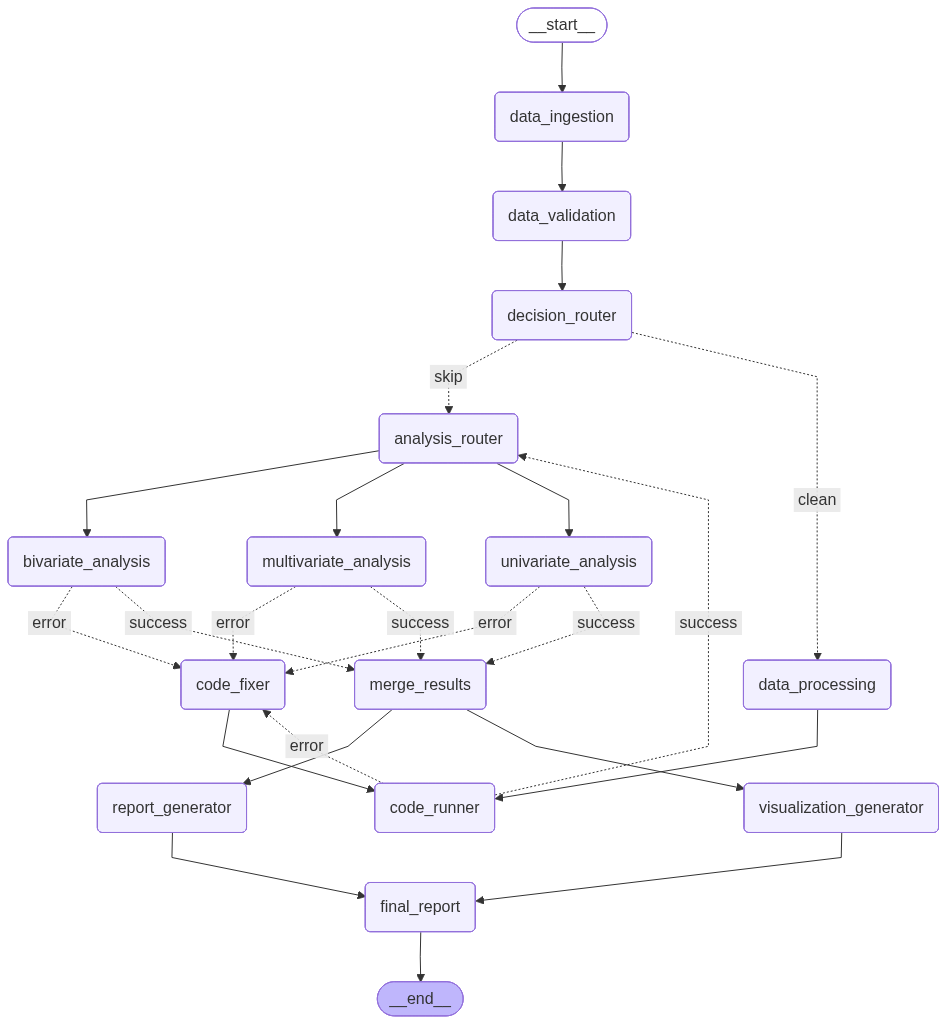

In [3]:
builder = StateGraph(AgentState)

builder.add_node("data_ingestion", data_ingestion)
builder.add_node("data_validation", data_validation)
builder.add_node("decision_router", decision_router)
builder.add_node("data_processing", data_processing)
builder.add_node("code_runner", code_runner)
builder.add_node("code_fixer", code_fixer)
builder.add_node("analysis_router", analysis_router)
builder.add_node("univariate_analysis", univariate_analysis)
builder.add_node("bivariate_analysis", bivariate_analysis)
builder.add_node("multivariate_analysis", multivariate_analysis)
builder.add_node("merge_results", merge_results)
builder.add_node("report_generator", report_generator)
builder.add_node("visualization_generator", visualization_generator)
builder.add_node("final_report" , final_report)
builder.set_entry_point("data_ingestion")


# Sequential pipeline
builder.add_edge("data_ingestion", "data_validation")
builder.add_edge("data_validation", "decision_router")


# Cleaning decision
builder.add_conditional_edges(
    "decision_router",
    lambda state: "clean" if state.get("cleaning_required") else "skip",
    {
        "clean": "data_processing",
        "skip": "analysis_router"
    }
)


# Code execution
builder.add_edge("data_processing", "code_runner")


builder.add_conditional_edges(
    "code_runner",
    lambda state: "error" if state.get("code_return_value") else "success",
    {
        "error": "code_fixer",
        "success": "analysis_router"
    }
)


builder.add_edge("code_fixer", "code_runner")


# Parallel workflow
builder.add_edge("analysis_router", "univariate_analysis")
builder.add_conditional_edges(
    "univariate_analysis",
    lambda state: "error" if state.get("code_return_value") else "success",
    {
        "error": "code_fixer",
        "success": "merge_results"
    }
)

builder.add_edge("analysis_router", "bivariate_analysis")
builder.add_conditional_edges(
    "bivariate_analysis",
    lambda state: "error" if state.get("code_return_value") else "success",
    {
        "error": "code_fixer",
        "success": "merge_results"
    }
)

builder.add_edge("analysis_router", "multivariate_analysis")
builder.add_conditional_edges(
    "multivariate_analysis",
    lambda state: "error" if state.get("code_return_value") else "success",
    {
        "error": "code_fixer",
        "success": "merge_results"
    }
)

# Merge results
#builder.add_edge("univariate_analysis", "merge_results")
# builder.add_edge("bivariate_analysis", "merge_results")
# builder.add_edge("multivariate_analysis", "merge_results")


builder.add_edge("merge_results", "report_generator")
builder.add_edge("merge_results", "visualization_generator")

builder.add_edge("report_generator" , "final_report")
builder.add_edge("visualization_generator" , "final_report")

builder.add_edge("final_report", END)

graph = builder.compile()

graph

# using SubGraphs

In [48]:
def uni_generate_code(state):
    return {}

def uni_run_code(state):
    return {"code_return_value": 0}

def uni_fix_code(state):
    return {}

def uni_finish(state):
    return {"univariate_result": "done"}


def build_univariate_graph():

    builder = StateGraph(AgentState)

    builder.add_node("generate_code", uni_generate_code)
    builder.add_node("run_code", uni_run_code)
    builder.add_node("fix_code", uni_fix_code)
    builder.add_node("finish", uni_finish)

    builder.set_entry_point("generate_code")

    builder.add_edge("generate_code", "run_code")

    builder.add_conditional_edges(
        "run_code",
        lambda s: "error" if s.get("code_return_value") else "success",
        {
            "error": "fix_code",
            "success": "finish"
        }
    )

    builder.add_edge("fix_code", "run_code")

    builder.add_edge("finish", END)

    return builder.compile()

In [49]:
from langgraph.graph import StateGraph, END


def bi_generate_code(state):
    """
    Generates code for bivariate analysis
    Example: correlation, scatter plots
    """
    return {}


def bi_run_code(state):
    """
    Executes generated bivariate analysis code
    """
    return {"code_return_value": 0}


def bi_fix_code(state):
    """
    Fixes bivariate code if execution fails
    """
    return {}


def bi_finish(state):
    """
    Stores final bivariate analysis results
    """
    return {"bivariate_result": "done"}


def build_bivariate_graph():

    builder = StateGraph(AgentState)

    builder.add_node("generate_code", bi_generate_code)
    builder.add_node("run_code", bi_run_code)
    builder.add_node("fix_code", bi_fix_code)
    builder.add_node("finish", bi_finish)

    builder.set_entry_point("generate_code")

    builder.add_edge("generate_code", "run_code")

    builder.add_conditional_edges(
        "run_code",
        lambda s: "error" if s.get("code_return_value") else "success",
        {
            "error": "fix_code",
            "success": "finish"
        }
    )

    builder.add_edge("fix_code", "run_code")

    builder.add_edge("finish", END)

    return builder.compile()

In [50]:
def multi_generate_code(state):
    """
    Generates code for multivariate analysis
    Example: pairplots, feature interactions, PCA
    """
    return {}


def multi_run_code(state):
    """
    Executes generated multivariate analysis code
    """
    return {"code_return_value": 0}


def multi_fix_code(state):
    """
    Fixes multivariate code if execution fails
    """
    return {}


def multi_finish(state):
    """
    Stores final multivariate analysis results
    """
    return {"multivariate_result": "done"}


def build_multivariate_graph():

    builder = StateGraph(AgentState)

    builder.add_node("generate_code", multi_generate_code)
    builder.add_node("run_code", multi_run_code)
    builder.add_node("fix_code", multi_fix_code)
    builder.add_node("finish", multi_finish)

    builder.set_entry_point("generate_code")

    builder.add_edge("generate_code", "run_code")

    builder.add_conditional_edges(
        "run_code",
        lambda s: "error" if s.get("code_return_value") else "success",
        {
            "error": "fix_code",
            "success": "finish"
        }
    )

    builder.add_edge("fix_code", "run_code")

    builder.add_edge("finish", END)

    return builder.compile()

In [51]:
univariate_graph = build_univariate_graph()
bivariate_graph = build_bivariate_graph()
multivariate_graph = build_multivariate_graph()

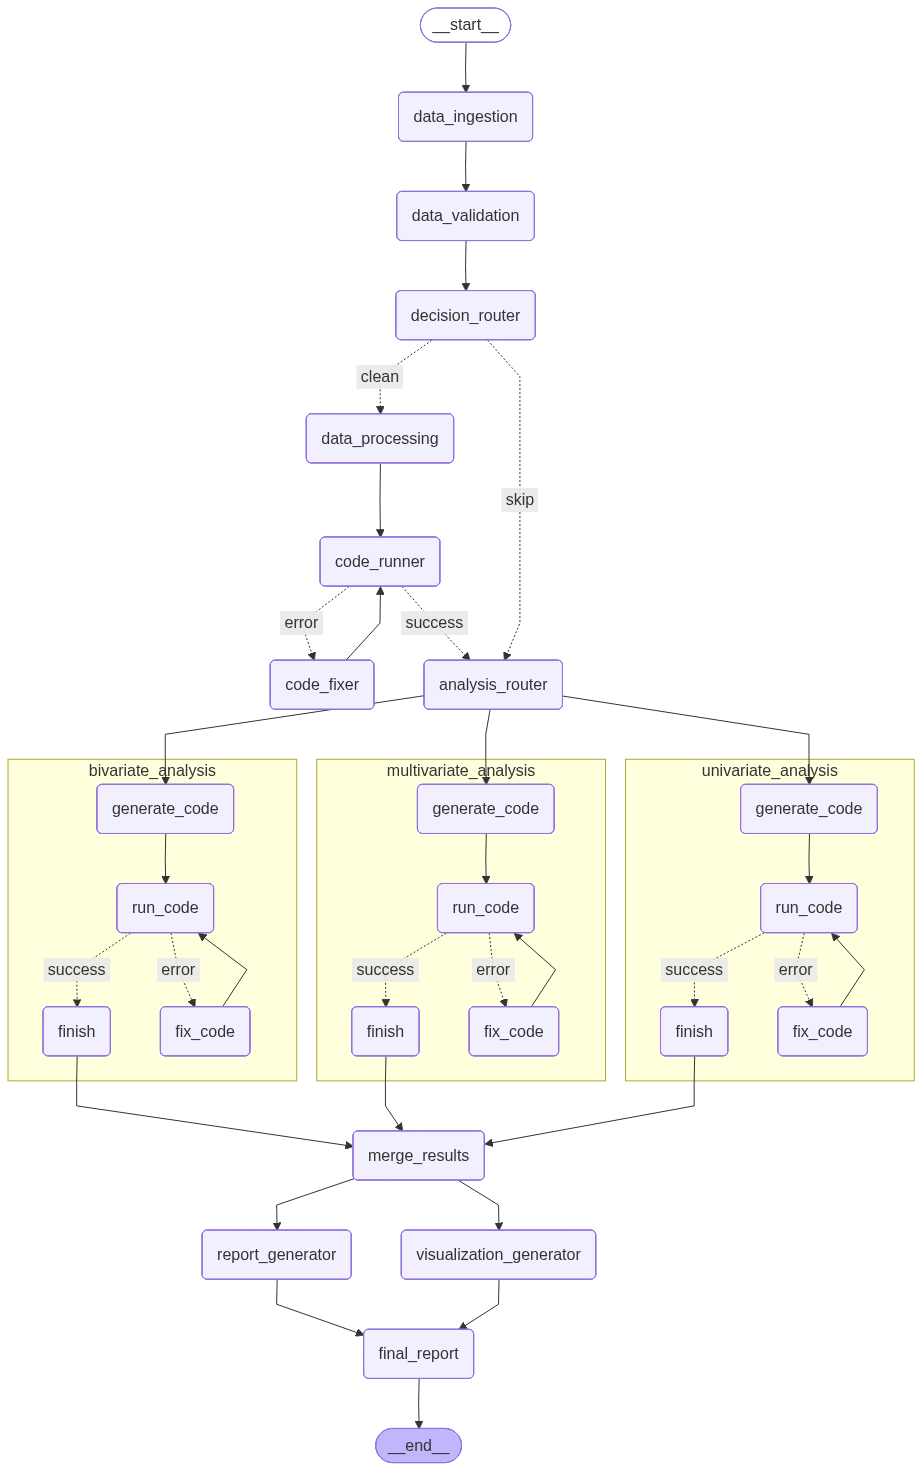

In [54]:
builder = StateGraph(AgentState)

builder.add_node("data_ingestion", data_ingestion)
builder.add_node("data_validation", data_validation)
builder.add_node("decision_router", decision_router)
builder.add_node("data_processing", data_processing)
builder.add_node("code_runner", code_runner)
builder.add_node("code_fixer", code_fixer)
builder.add_node("analysis_router", analysis_router)
builder.add_node("univariate_analysis", univariate_graph)
builder.add_node("bivariate_analysis", bivariate_graph)
builder.add_node("multivariate_analysis", multivariate_graph)
builder.add_node("merge_results", merge_results)
builder.add_node("report_generator", report_generator)
builder.add_node("visualization_generator", visualization_generator)
builder.add_node("final_report" , final_report)
builder.set_entry_point("data_ingestion")


# Sequential pipeline
builder.add_edge("data_ingestion", "data_validation")
builder.add_edge("data_validation", "decision_router")


# Cleaning decision
builder.add_conditional_edges(
    "decision_router",
    lambda state: "clean" if state.get("cleaning_required") else "skip",
    {
        "clean": "data_processing",
        "skip": "analysis_router"
    }
)


# Code execution
builder.add_edge("data_processing", "code_runner")


builder.add_conditional_edges(
    "code_runner",
    lambda state: "error" if state.get("code_return_value") else "success",
    {
        "error": "code_fixer",
        "success": "analysis_router"
    }
)


builder.add_edge("code_fixer", "code_runner")


# Parallel workflow
builder.add_edge("analysis_router", "univariate_analysis")

builder.add_edge("analysis_router", "bivariate_analysis")

builder.add_edge("analysis_router", "multivariate_analysis")


# Merge results
builder.add_edge("univariate_analysis", "merge_results")
builder.add_edge("bivariate_analysis", "merge_results")
builder.add_edge("multivariate_analysis", "merge_results")

builder.add_edge("merge_results", "report_generator")
builder.add_edge("merge_results", "visualization_generator")

builder.add_edge("report_generator" , "final_report")
builder.add_edge("visualization_generator" , "final_report")

builder.add_edge("final_report", END)

graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))